# Does Neural Network perform better ? - Check

In [ ]:
!pip install scikeras
!pip install scikit-learn==1.4.2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
import warnings

warnings.filterwarnings('ignore')
from scikeras.wrappers import KerasRegressor,KerasClassifier
# from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import GridSearchCV, cross_validate, train_test_split,RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from keras.utils import to_categorical

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 73.3 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
hdbscan 0.8.44 requires scikit-learn>=1.6, but you have scikit-learn 1.4.2 which is incompatible.
umap-learn 0.5.12 requires scikit-learn>=1.6, but you have scikit-learn 1.4.2 which is incompatible.


In [ ]:
mental_health = pd.read_csv("data/mental_health_risk_dataset.csv")
mental_health.head()

,age,gender,marital_status,education_level,employment_status,sleep_hours,physical_activity_hours_per_week,screen_time_hours_per_day,social_support_score,work_stress_level,...,depression_score,stress_level,mood_swings_frequency,concentration_difficulty_level,panic_attack_history,family_history_mental_illness,previous_mental_health_diagnosis,therapy_history,substance_use,mental_health_risk
0,56,Other,Single,Bachelor,Unemployed,8.6,2.8,9.6,7,10,...,4,8,8,3,1,0,1,1,1,1
1,47,Male,Single,Bachelor,Unemployed,4.5,2.7,3.0,10,6,...,7,4,9,3,0,0,0,0,0,0
2,56,Female,Divorced,Bachelor,Student,3.1,14.1,7.2,10,5,...,3,1,4,2,1,1,1,1,1,2
3,59,Other,Married,Bachelor,Employed,7.0,0.5,10.3,2,10,...,8,5,2,5,1,1,0,1,1,2
4,58,Male,Single,High School,Self-Employed,5.1,2.5,1.2,8,1,...,8,3,3,1,0,0,1,0,1,0


In [ ]:
# Make a copy to apply feature engineering without modifying the original sample_data
new_data_engineered_df = mental_health.copy()

# ==========================================
# 1. COMPOSITE CLINICAL & PSYCHOLOGICAL SCORES
# ==========================================
new_data_engineered_df['total_distress_score'] = new_data_engineered_df['anxiety_score'] + new_data_engineered_df['depression_score'] + new_data_engineered_df['stress_level']
new_data_engineered_df['situational_stress_load'] = new_data_engineered_df['work_stress_level'] + new_data_engineered_df['academic_pressure_level'] + new_data_engineered_df['financial_stress_level']


# ==========================================
# 2. LIFESTYLE BALANCE & INTERACTION METRICS
# ==========================================
new_data_engineered_df['work_to_sleep_ratio'] = new_data_engineered_df['working_hours_per_week'] / (new_data_engineered_df['sleep_hours'] * 7 + 1)
new_data_engineered_df['active_vs_screen_ratio'] = (new_data_engineered_df['physical_activity_hours_per_week'] / 7) / (new_data_engineered_df['screen_time_hours_per_day'] + 1)

# ==========================================
# 3. CLINICAL BACKGROUND & VULNERABILITY INDEX
# ==========================================
history_cols_new = ['panic_attack_history', 'family_history_mental_illness', 'previous_mental_health_diagnosis', 'substance_use','therapy_history']
new_data_engineered_df['clinical_vulnerability_index'] = new_data_engineered_df[history_cols_new].sum(axis=1)
new_data_engineered_df['protective_buffer_score'] = (new_data_engineered_df['social_support_score'] + new_data_engineered_df['job_satisfaction_score']) - new_data_engineered_df['work_stress_level']

# ==========================================
# 4. CATEGORICAL ENCODING & DEMOGRAPHICS
# ==========================================
new_data_engineered_df['age_group'] = pd.cut(new_data_engineered_df['age'],
                         bins=[0, 24, 34, 50, 100],
                         labels=['Youth', 'Young_Adult', 'Adult', 'Senior'])


# ==========================================
# 5. TARGET COLUMN CATEGORICAL LABEL
# ==========================================
# Define bins and labels
bins = [-1,0,1, 2]
labels = ['Low Risk', 'Medium Risk', 'High Risk']

# Apply mapping to dataframe column
new_data_engineered_df['risk_level'] = pd.cut(new_data_engineered_df['mental_health_risk'], bins=bins, labels=labels)

# Identify all numeric columns after feature engineering
# This will include original numeric columns and newly created numeric columns
numeric_cols_for_prediction = new_data_engineered_df.select_dtypes(include=[np.number]).columns.tolist()


# New derived numeric features
new_numeric_derived_features = ['total_distress_score', 'situational_stress_load', 'work_to_sleep_ratio',
                                'active_vs_screen_ratio', 'clinical_vulnerability_index', 'protective_buffer_score',
                                'age_group']
other_features_from_original_dataset = ['gender','marital_status','education_level','employment_status','mood_swings_frequency'
                                  ,'concentration_difficulty_level','mental_health_risk','risk_level']
# Combine all numeric features for the model input
all_features_for_model = other_features_from_original_dataset + new_numeric_derived_features


print("Engineered new data (first 5 rows, showing only features relevant for prediction by the current model):")
display(new_data_engineered_df[all_features_for_model].head())
new_data_engineered_df[all_features_for_model].shape


Engineered new data (first 5 rows, showing only features relevant for prediction by the current model):


,gender,marital_status,education_level,employment_status,mood_swings_frequency,concentration_difficulty_level,mental_health_risk,risk_level,total_distress_score,situational_stress_load,work_to_sleep_ratio,active_vs_screen_ratio,clinical_vulnerability_index,protective_buffer_score,age_group
0,Other,Single,Bachelor,Unemployed,8,3,1,Medium Risk,17,21,0.653595,0.037736,4,4,Senior
1,Male,Single,Bachelor,Unemployed,9,3,0,Low Risk,14,25,0.953846,0.096429,0,5,Adult
2,Female,Divorced,Bachelor,Student,4,2,2,High Risk,12,14,1.233480,0.245645,5,9,Senior
3,Other,Married,Bachelor,Employed,2,5,2,High Risk,22,21,1.260000,0.006321,4,0,Senior
4,Male,Single,High School,Self-Employed,3,1,0,Low Risk,12,12,0.762943,0.162338,2,15,Senior


(25000, 15)

In [ ]:
# Create a final feature engineered dataframe
mental_health_engineered_final_df = new_data_engineered_df[all_features_for_model]
mental_health_engineered_final_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 15 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   gender                          25000 non-null  object  
 1   marital_status                  25000 non-null  object  
 2   education_level                 25000 non-null  object  
 3   employment_status               25000 non-null  object  
 4   mood_swings_frequency           25000 non-null  int64   
 5   concentration_difficulty_level  25000 non-null  int64   
 6   mental_health_risk              25000 non-null  int64   
 7   risk_level                      25000 non-null  category
 8   total_distress_score            25000 non-null  int64   
 9   situational_stress_load         25000 non-null  int64   
 10  work_to_sleep_ratio             25000 non-null  float64 
 11  active_vs_screen_ratio          25000 non-null  float64 
 12  clinical_vulnerabi

In [ ]:
X = mental_health_engineered_final_df.drop(columns='mental_health_risk')
y = to_categorical(mental_health_engineered_final_df['mental_health_risk'])

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
# Identify numeric & categorical columns

categorical_cols = mental_health_engineered_final_df.select_dtypes(include=["object","category"]).columns
numeric_cols = mental_health_engineered_final_df.select_dtypes(include=[np.number]).columns
# risk_level is created to use in plots &  not required for modelling
categorical_cols = [col for col in categorical_cols if col != 'risk_level']
print("\nCategorical columns:")
print(categorical_cols)
print("\nNumeric columns:")
print(numeric_cols)


Categorical columns:
['gender', 'marital_status', 'education_level', 'employment_status', 'age_group']

Numeric columns:
Index(['mood_swings_frequency', 'concentration_difficulty_level',
       'mental_health_risk', 'total_distress_score', 'situational_stress_load',
       'work_to_sleep_ratio', 'active_vs_screen_ratio',
       'clinical_vulnerability_index', 'protective_buffer_score'],
      dtype='object')


In [ ]:
# numerical_cols_generic_evaluation = [col for col in numeric_cols if col != ['mental_health_risk','active_vs_screen_ratio','work_to_sleep_ratio']]
# print(numerical_cols_generic_evaluation)
log_transformation_cols = ['active_vs_screen_ratio', 'work_to_sleep_ratio']
print(log_transformation_cols)
numerical_cols_generic_evaluation = [col for col in numeric_cols if col not in ['mental_health_risk','risk_level'] + log_transformation_cols]
print(numerical_cols_generic_evaluation)

['active_vs_screen_ratio', 'work_to_sleep_ratio']
['mood_swings_frequency', 'concentration_difficulty_level', 'total_distress_score', 'situational_stress_load', 'clinical_vulnerability_index', 'protective_buffer_score']


In [ ]:
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
# ... (other imports)

column_transformer = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols_generic_evaluation),
        ('cat', OneHotEncoder(drop='first'), categorical_cols),
        ('log', FunctionTransformer(np.log1p, validate=True, feature_names_out='one-to-one'), log_transformation_cols)
    ]
)

In [ ]:
print(f'numeric columns ={numerical_cols_generic_evaluation}')
print(f'numeric log transformation columns ={log_transformation_cols}')
print(f'categorical columns={categorical_cols}')

numeric columns =['mood_swings_frequency', 'concentration_difficulty_level', 'total_distress_score', 'situational_stress_load', 'clinical_vulnerability_index', 'protective_buffer_score']
numeric log transformation columns =['active_vs_screen_ratio', 'work_to_sleep_ratio']
categorical columns=['gender', 'marital_status', 'education_level', 'employment_status', 'age_group']


In [ ]:
tf.random.set_seed(42)
# Function to create a fully connected neural network model for SciKeras
def create_model(optimizer='adam', neurons=50, activation='relu', input_dim=21):
    model = tf.keras.models.Sequential()
    model.add(tf.keras.layers.Dense(neurons, activation=activation, input_shape=(input_dim,)))
    model.add(tf.keras.layers.Dense(neurons, activation=activation, input_shape=(input_dim,)))
    model.add(tf.keras.layers.Dense(neurons, activation=activation, input_shape=(input_dim,)))
    # model.add(tf.keras.layers.Dense(neurons, activation=activation))
    # model.add(tf.keras.layers.Dense(1))  # Output layer for regression
    model.add(tf.keras.layers.Dense(3, activation='softmax'))
    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics= ['accuracy'])
    return model

In [ ]:
tf.random.set_seed(42)

# Keras model with SciKeras wrapper
def build_nn_model(optimizer='adam', neurons=50, activation='relu', input_dim=21):
    return create_model(optimizer=optimizer, neurons=neurons, activation=activation, input_dim=input_dim) # Pass parameters to create_model


model = KerasClassifier(model=build_nn_model, validation_split=0.2,epochs=20,  batch_size=50,verbose=2)

In [ ]:
from sklearn.pipeline import Pipeline
pipeline = Pipeline(steps=[('preprocessor', column_transformer),
                           ('model', model)
                           ])

In [ ]:
tf.random.set_seed(42)
history = pipeline.fit(X_train, y_train)

Epoch 1/20
320/320 - 7s - 21ms/step - accuracy: 0.5645 - loss: 0.8809 - val_accuracy: 0.5863 - val_loss: 0.8499
Epoch 2/20
320/320 - 2s - 5ms/step - accuracy: 0.5949 - loss: 0.8329 - val_accuracy: 0.5890 - val_loss: 0.8366
Epoch 3/20
320/320 - 3s - 8ms/step - accuracy: 0.6030 - loss: 0.8181 - val_accuracy: 0.5925 - val_loss: 0.8322
Epoch 4/20
320/320 - 3s - 9ms/step - accuracy: 0.6071 - loss: 0.8099 - val_accuracy: 0.5918 - val_loss: 0.8307
Epoch 5/20
320/320 - 2s - 6ms/step - accuracy: 0.6112 - loss: 0.8043 - val_accuracy: 0.5882 - val_loss: 0.8312
Epoch 6/20
320/320 - 2s - 5ms/step - accuracy: 0.6139 - loss: 0.7997 - val_accuracy: 0.5890 - val_loss: 0.8326
Epoch 7/20
320/320 - 3s - 8ms/step - accuracy: 0.6163 - loss: 0.7958 - val_accuracy: 0.5872 - val_loss: 0.8348
Epoch 8/20
320/320 - 3s - 10ms/step - accuracy: 0.6177 - loss: 0.7920 - val_accuracy: 0.5857 - val_loss: 0.8361
Epoch 9/20
320/320 - 3s - 10ms/step - accuracy: 0.6201 - loss: 0.7882 - val_accuracy: 0.5913 - val_loss: 0.837

In [ ]:
print(history.score(X_train, y_train))
print(history.score(X_test, y_test))

400/400 - 0s - 1ms/step
0.6361
100/100 - 0s - 2ms/step
0.5784


In [ ]:
print(history)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['mood_swings_frequency',
                                                   'concentration_difficulty_level',
                                                   'total_distress_score',
                                                   'situational_stress_load',
                                                   'clinical_vulnerability_index',
                                                   'protective_buffer_score']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['gender', 'marital_status',
                                                   'education_level',
                                                   'employment_status',
                                                   'age_gr

In [ ]:
# find recall/ f1-score & precision
from sklearn.metrics import recall_score, precision_score, f1_score,roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import label_binarize

y_pred = pipeline.predict(X_test)
# Calculate recall, precision, and F1-score
recall = recall_score(y_test, y_pred, average='weighted')
precision = precision_score(y_test, y_pred, average='weighted')
f1_score = f1_score(y_test, y_pred, average='weighted')
#
print(recall)
print(precision)
print(f1_score)

100/100 - 0s - 1ms/step
0.5784
0.5842715037141901
0.5762051803316388


In [ ]:
# y_test is already one-hot encoded, so we can directly use it.
n_classes = y_test.shape[1]

y_prob = pipeline.predict_proba(X_test)

100/100 - 0s - 1ms/step


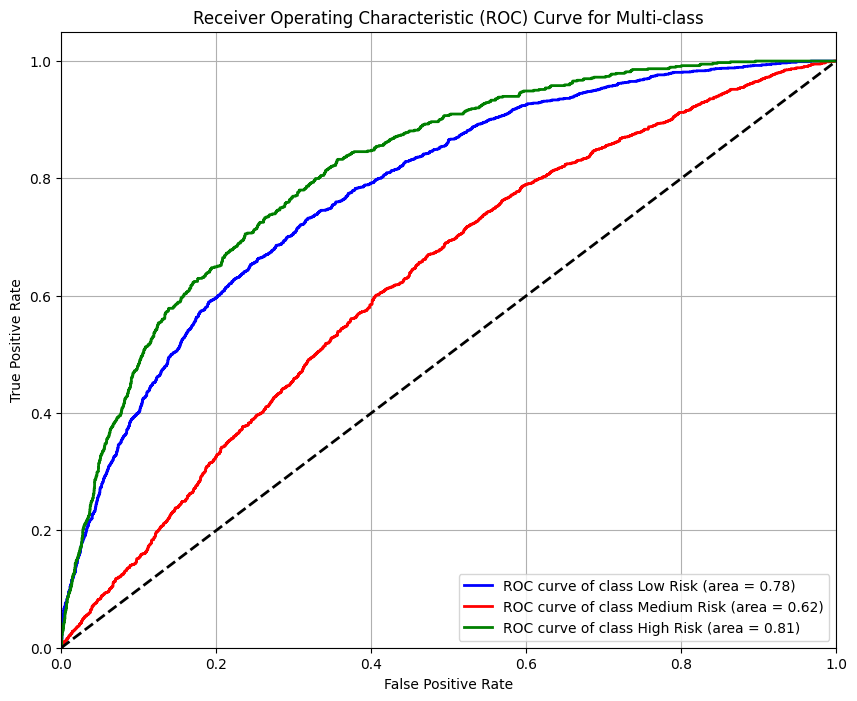

In [ ]:
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(10, 8))
colors = ['blue', 'red', 'green']
risk_labels = ['Low Risk', 'Medium Risk', 'High Risk']

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label='ROC curve of class {0} (area = {1:0.2f})'.format(risk_labels[i], roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Multi-class')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

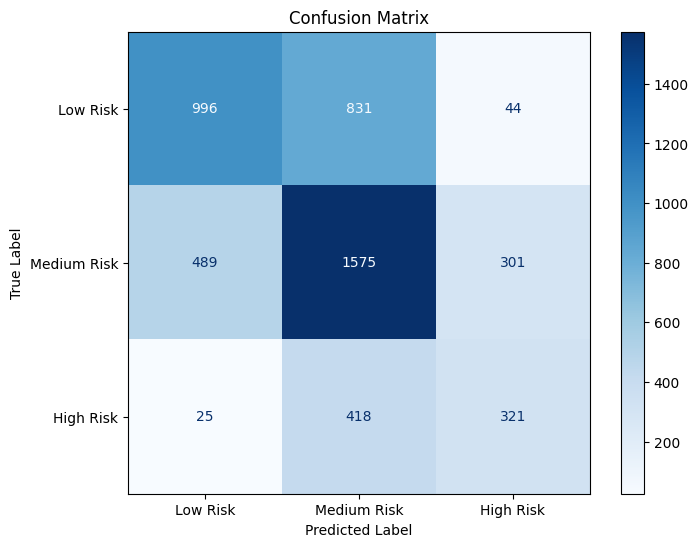

[0 1 2 ... 1 0 0]
[0 2 2 ... 1 1 1]


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Convert one-hot encoded y_test and y_pred back to single class labels
y_test_labels = np.argmax(y_test, axis=1)
y_pred_labels = np.argmax(y_pred, axis=1)

# Define the labels for the confusion matrix
risk_labels = ['Low Risk', 'Medium Risk', 'High Risk']

# Compute the confusion matrix
cm = confusion_matrix(y_test_labels, y_pred_labels)

# Display the confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=risk_labels)
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

print(y_test_labels)
print(y_pred_labels)

In [ ]:
from sklearn.metrics import classification_report

# Generate and display the classification report
report = classification_report(y_test_labels, y_pred_labels, target_names=risk_labels)
print("Classification Report:\n", report)

Classification Report:
               precision    recall  f1-score   support

    Low Risk       0.66      0.53      0.59      1871
 Medium Risk       0.56      0.67      0.61      2365
   High Risk       0.48      0.42      0.45       764

    accuracy                           0.58      5000
   macro avg       0.57      0.54      0.55      5000
weighted avg       0.58      0.58      0.58      5000



### Implementing Class Weights to Address Imbalance

When dealing with imbalanced datasets, models tend to perform poorly on minority classes because they see fewer examples of these classes during training. Class weights can mitigate this by assigning a higher penalty to misclassifications of minority classes. This forces the model to pay more attention to correctly classifying these underrepresented instances.

Here's a step-by-step guide to implement class weights:

1.  **Calculate Class Weights**: Use `sklearn.utils.class_weight.compute_class_weight` to automatically calculate weights for each class based on their distribution in the training data. This function can compute weights inversely proportional to class frequencies, giving higher weights to minority classes.
2.  **Pass Weights to Model Training**: In Keras, I can pass these calculated class weights to the `fit` method of my model using the `class_weight` parameter. This will adjust the loss contribution for each sample based on its true class.

Let's apply this to our model:

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Get the true labels from the one-hot encoded y_train
y_train_labels = np.argmax(y_train, axis=1)

# Calculate class weights
# 'balanced' mode automatically calculates weights inversely proportional to class frequencies
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_labels),
    y=y_train_labels
)

# Convert to a dictionary for Keras
class_weight_dict = dict(enumerate(class_weights))

print("Calculated Class Weights:", class_weight_dict)


Calculated Class Weights: {0: np.float64(0.890551251224508), 1: np.float64(0.704870656234581), 2: np.float64(2.181500872600349)}


Now that we have the class weights, we'll retrain the pipeline with these weights. This involves modifying the `KerasClassifier` model instantiation to accept these weights. Since the `class_weight` parameter is typically passed to the `fit` method, we need to adjust our pipeline training.

In [ ]:
# Retrain the pipeline with class weights
# We need to recreate the KerasClassifier instance or fit it again with class_weight
tf.random.set_seed(42)

# Re-instantiate the model to ensure a fresh start or simply fit again
# If I defined my KerasClassifier with class_weight in model=build_nn_model,
# it won't work for pipeline directly. I need to pass class_weight to pipeline.fit()

# The current KerasClassifier is inside the pipeline. Let's refit the pipeline with class_weight.

history_weighted = pipeline.fit(X_train, y_train, model__class_weight=class_weight_dict)

print("Pipeline training with class weights complete.")

# Evaluate the model with class weights
print("Accuracy (Train) with class weights:", history_weighted.score(X_train, y_train))
print("Accuracy (Test) with class weights:", history_weighted.score(X_test, y_test))


Epoch 1/20
320/320 - 2s - 7ms/step - accuracy: 0.4740 - loss: 0.9130 - val_accuracy: 0.5033 - val_loss: 0.9370
Epoch 2/20
320/320 - 1s - 3ms/step - accuracy: 0.5242 - loss: 0.8563 - val_accuracy: 0.5220 - val_loss: 0.9247
Epoch 3/20
320/320 - 1s - 2ms/step - accuracy: 0.5389 - loss: 0.8436 - val_accuracy: 0.5272 - val_loss: 0.9204
Epoch 4/20
320/320 - 1s - 2ms/step - accuracy: 0.5462 - loss: 0.8364 - val_accuracy: 0.5257 - val_loss: 0.9195
Epoch 5/20
320/320 - 1s - 4ms/step - accuracy: 0.5510 - loss: 0.8310 - val_accuracy: 0.5335 - val_loss: 0.9191
Epoch 6/20
320/320 - 1s - 4ms/step - accuracy: 0.5549 - loss: 0.8265 - val_accuracy: 0.5370 - val_loss: 0.9197
Epoch 7/20
320/320 - 1s - 3ms/step - accuracy: 0.5562 - loss: 0.8223 - val_accuracy: 0.5372 - val_loss: 0.9218
Epoch 8/20
320/320 - 1s - 2ms/step - accuracy: 0.5605 - loss: 0.8187 - val_accuracy: 0.5383 - val_loss: 0.9248
Epoch 9/20
320/320 - 1s - 2ms/step - accuracy: 0.5629 - loss: 0.8148 - val_accuracy: 0.5370 - val_loss: 0.9263
E

After retraining with class weights, let's re-evaluate the model's performance using the classification report to see if there's an improvement, especially for the 'High Risk' class.

100/100 - 0s - 2ms/step
Classification Report (with Class Weights):
               precision    recall  f1-score   support

    Low Risk       0.65      0.59      0.62      1871
 Medium Risk       0.56      0.41      0.47      2365
   High Risk       0.34      0.71      0.46       764

    accuracy                           0.52      5000
   macro avg       0.52      0.57      0.52      5000
weighted avg       0.56      0.52      0.52      5000



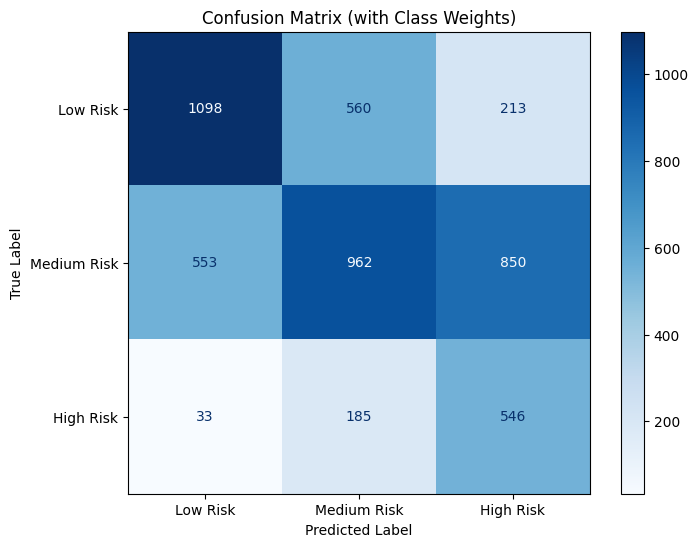

In [ ]:
# Predict with the weighted model
y_pred_weighted = pipeline.predict(X_test)

# Convert predictions back to labels
y_pred_labels_weighted = np.argmax(y_pred_weighted, axis=1)

# Generate and display the new classification report
report_weighted = classification_report(y_test_labels, y_pred_labels_weighted, target_names=risk_labels)
print("Classification Report (with Class Weights):\n", report_weighted)

# Re-compute and display the confusion matrix for the weighted model
cm_weighted = confusion_matrix(y_test_labels, y_pred_labels_weighted)

fig, ax = plt.subplots(figsize=(8, 6))
disp_weighted = ConfusionMatrixDisplay(confusion_matrix=cm_weighted, display_labels=risk_labels)
disp_weighted.plot(cmap=plt.cm.Blues, ax=ax)
plt.title('Confusion Matrix (with Class Weights)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Implementeting class weights, the minority class in CLASS IMBALANCE (HIGH RISK) has significanly

* HIGH RISK - increased from 321 to to 546
* LOW RISK - increased from 996 to 1098

### Hyperparameter Tuning with RandomizedSearchCV

Now that we've introduced class weights, let's try to optimize the neural network's architecture and training parameters to achieve better overall performance. We will use `RandomizedSearchCV` to efficiently search for optimal hyperparameters.

We'll define a parameter distribution to sample from, including:
*   `model__neurons`: Number of neurons in the first dense layer.
*   `model__epochs`: Number of training epochs.
*   `model__batch_size`: Batch size for training.
*   `model__optimizer`: The optimization algorithm.
*   `model__activation`: Activation function for hidden layers.

We will also ensure that the `class_weight_dict` is passed to the `fit` method of the `KerasClassifier` within `RandomizedSearchCV`.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

# Define the parameter distribution for RandomizedSearchCV
param_dist = {
    'model__neurons': randint(50, 200), # Number of neurons in the first dense layer
    'model__epochs': randint(20, 100), # Number of training epochs
    'model__batch_size': randint(64, 128), # Batch size
    'model__optimizer': ['adam', 'rmsprop'],
    'model__activation': ['relu', 'tanh']
}

# Create a KerasClassifier instance (it will be re-initialized by GridSearchCV)
# We'll pass the build_nn_model function which creates the base NN structure
# Note: input_dim is handled in build_nn_model and passed to create_model
# Explicitly pass model-specific parameters to KerasClassifier constructor with default values
kera_model_for_search = KerasClassifier(
    model=build_nn_model,
    verbose=0,
    input_dim=21, # Fixed input_dim
    optimizer='adam', # Default, will be overridden
    neurons=50,       # Default, will be overridden
    activation='relu',# Default, will be overridden
    batch_size=32,    # Default, will be overridden
    epochs=50         # Default, will be overridden
)

# Re-create the pipeline with the KerasClassifier instance for search
pipeline_for_search = Pipeline(steps=[('preprocessor', column_transformer),
                                    ('model', kera_model_for_search)])

# Create RandomizedSearchCV object
# n_iter: Number of parameter settings that are sampled. Trades off execution time with quality of solution.
# cv: Number of cross-validation folds.
random_search = RandomizedSearchCV(estimator=pipeline_for_search,
                                   param_distributions=param_dist,
                                   n_iter=10, # Number of different combinations to try
                                   cv=3, # 3-fold cross-validation
                                   scoring='f1_weighted', # Optimize for weighted F1-score
                                   verbose=2,
                                   random_state=42,
                                   n_jobs=-1) # Use all available CPU cores

# ... (setup code for KerasClassifier and RandomizedSearchCV)
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)

# Pass callback in fit()
# random_search.fit(X_train, y_train, validation_split=0.1, callbacks=[early_stop])



print("Starting RandomizedSearchCV...")
# Fit RandomizedSearchCV, passing class weights and callbacks to the model's fit method within the pipeline
random_search.fit(X_train, y_train,model__class_weight=class_weight_dict, model__callbacks=[early_stop], model__validation_split=0.2)

print("RandomizedSearchCV complete.")

# Get the best model and its parameters
best_model = random_search.best_estimator_
best_params = random_search.best_params_

print("Best parameters found:", best_params)
print("Best F1-weighted score:", random_search.best_score_)

Starting RandomizedSearchCV...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
RandomizedSearchCV complete.
Best parameters found: {'model__activation': 'tanh', 'model__batch_size': 103, 'model__epochs': 43, 'model__neurons': 180, 'model__optimizer': 'rmsprop'}
Best F1-weighted score: 0.5292610862709365


After finding the best hyperparameters, let's evaluate the performance of this optimized model on the test set using the classification report and confusion matrix.

Classification Report (after Hyperparameter Tuning with Class Weights):
               precision    recall  f1-score   support

    Low Risk       0.62      0.64      0.63      1871
 Medium Risk       0.57      0.45      0.51      2365
   High Risk       0.35      0.54      0.42       764

    accuracy                           0.54      5000
   macro avg       0.51      0.54      0.52      5000
weighted avg       0.55      0.54      0.54      5000



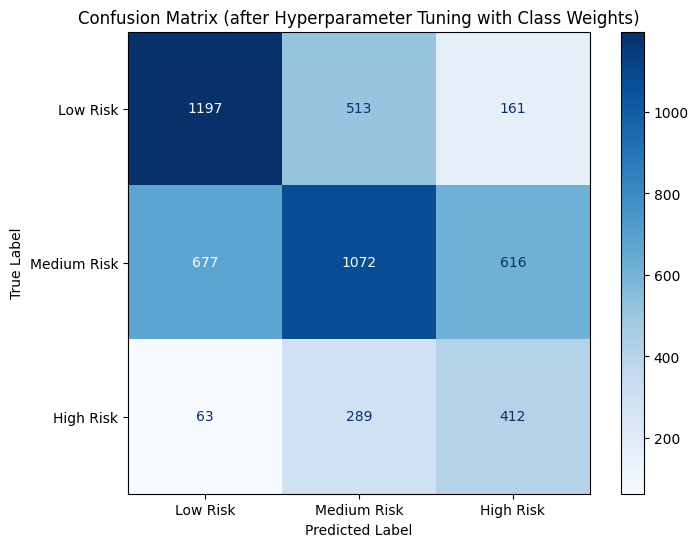

In [ ]:
# Predict with the best model from RandomizedSearchCV
y_pred_tuned = best_model.predict(X_test)

# Convert predictions back to labels
y_pred_labels_tuned = np.argmax(y_pred_tuned, axis=1)

# Generate and display the new classification report
report_tuned = classification_report(y_test_labels, y_pred_labels_tuned, target_names=risk_labels)
print("Classification Report (after Hyperparameter Tuning with Class Weights):\n", report_tuned)

# Re-compute and display the confusion matrix for the tuned model
cm_tuned = confusion_matrix(y_test_labels, y_pred_labels_tuned)

fig, ax = plt.subplots(figsize=(8, 6))
disp_tuned = ConfusionMatrixDisplay(confusion_matrix=cm_tuned, display_labels=risk_labels)
disp_tuned.plot(cmap=plt.cm.Blues, ax=ax)
plt.title('Confusion Matrix (after Hyperparameter Tuning with Class Weights)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Draw ROC-AUC with tuned model

In [ ]:
n_classes = y_test.shape[1]

y_prob_tuned = best_model.predict_proba(X_test)
print(y_prob_tuned)

[[0.31406936 0.6522329  0.03369771]
 [0.02912666 0.10593566 0.8649377 ]
 [0.08374955 0.5931644  0.32308602]
 ...
 [0.28616092 0.5319711  0.181868  ]
 [0.21979544 0.32936844 0.45083612]
 [0.1262621  0.54714626 0.32659152]]


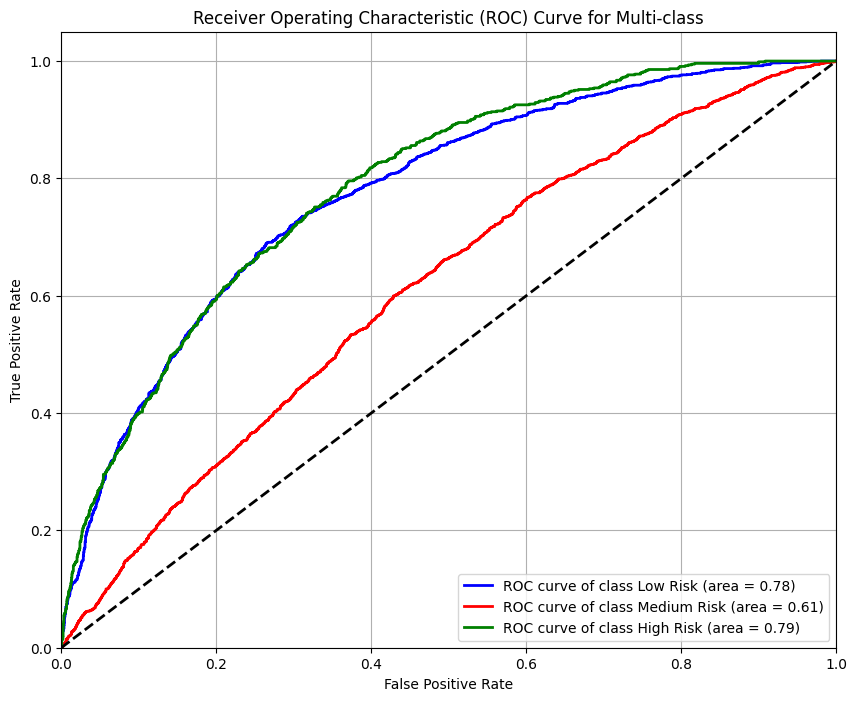

In [ ]:
# plot ROC-AUC with best_model from Randomized search

fpr_tuned = dict()
tpr_tuned = dict()
roc_auc_tuned = dict()
for i in range(n_classes):
    # Use prediction probabilities (y_prob_tuned) instead of hard predictions (y_pred_tuned)
    fpr_tuned[i], tpr_tuned[i], _ = roc_curve(y_test[:, i], y_prob_tuned[:, i])
    roc_auc_tuned[i] = auc(fpr_tuned[i], tpr_tuned[i])

plt.figure(figsize=(10,8))
colors = ['blue', 'red', 'green']

risk_labels = ['Low Risk', 'Medium Risk', 'High Risk']

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr_tuned[i], tpr_tuned[i], color=color, lw=2,
             label='ROC curve of class {0} (area = {1:0.2f})'.format(risk_labels[i], roc_auc_tuned[i]))

plt.plot([0, 1], [0, 1], 'k--', lw= 2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Multi-class')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

The ROC-AUC scores for my model did not improve significantly, and even slightly decreased for some classes, after applying class weights and hyperparameter tuning. Here's a breakdown of why this might be the case:

1. **Impact of Class Weights:** The primary goal of **introducing class weights (as seen in the classification report with class weights before tuning) was to improve the model's ability to identify the 'High Risk' class, which is likely a minority class**. This strategy typically shifts the model's decision boundary to favor the minority class, leading to:

     * **Increased Recall for Minority Class:** For the 'High Risk' class, recall significantly improved from 0.42 (initial) to 0.71 (with class weights), then settled at 0.54 (tuned). This means the model is better at catching true 'High Risk' instances.
     * **Decreased Precision for Minority Class:** This often comes at the cost of precision. For 'High Risk', precision dropped from 0.48 (initial) to 0.34 (with class weights), and remained low at 0.35 (tuned). The model might be predicting more 'High Risk' cases, but many of these predictions could be incorrect (false positives).
    * **Overall Accuracy/AUC Trade-off:** While beneficial for handling imbalanced data, this rebalancing doesn't always translate to a higher overall AUC. AUC measures the model's ability to discriminate between classes across all possible classification thresholds. By shifting the focus with class weights, I am optimizing for a different performance metric (like F1-score for the minority class) rather than purely discrimination power, which might keep the AUC stable or even slightly lower if it introduces more false positives or misclassifications in other classes.
2. **Dataset Limitations:** It's possible that the dataset itself has inherent limitations. If the different risk classes are not clearly separable in the feature space (i.e., their features overlap considerably), even the most sophisticated model or extensive tuning might struggle to achieve higher discriminative power, thus capping the achievable AUC.

3. **Model Architecture:** While I tuned parameters like neurons, epochs, batch size, optimizer, and activation function, the fundamental architecture of the neural network (e.g., number of layers, types of layers) remained the same. If the problem is complex, a more intricate or different neural network design might be necessary to capture more nuanced patterns and improve overall discrimination.

4. **Limited Search Space for Hyperparameter Tuning:** Although RandomizedSearchCV is efficient, the n_iter (number of samples) was set to 10 and cv (cross-validation folds) to 3. A more exhaustive search with a larger n_iter or a wider range of parameter distributions could potentially uncover slightly better combinations, but this is often constrained by computational resources.

In essence, the tuning process, particularly with class weights, helped to adjust the model's behavior to be more sensitive to the 'High Risk' class (improving recall for that class), but it did not lead to a significant improvement in the model's overall ability to distinguish between all classes, as reflected by the similar ROC-AUC scores.

**Neural Network - Result & Analysis**

Classification Report:
               
               precision    recall  f1-score   support

    Low Risk       0.66      0.53      0.59      1871
    Medium Risk    0.56      0.67      0.1      2365
    High Risk      0.48      0.42      0.45       764

This Metrics are close to LogisticRegression/XGBoost  but NOT better. So **Neural Network didn't add any extra value.**

# Final recommendation

1. See analysis_with_feature_engg.ipynb notebook